In [1]:
!pip install langchain langgraph langchain-community chromadb sqlite-utils

C:\Users\campus4D025\AppData\Local\Temp\ipykernel_13264\1305325563.py:15: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  llm = Ollama(model="exaone3.5:2.4b")


LangGraph 구조
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | matcher |   
 +---------+   
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


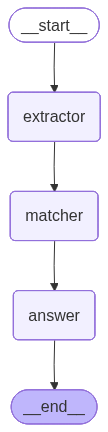


 추출된 상태
체력, 살 찌는 상태

추천 운동 후보
걷기, 가벼운 스트레칭, 요가 동작, 수영, 자전거 타기, 계단 오르내리기

 최종 응답
현재 상태 요약
- 체력이 낮은 상태로 체력 향상이 필요함
- 체중 증가 우려로 꾸준한 운동이 중요함

추천 운동 리스트
- 걷기: 일상 활동에 쉽게 포함할 수 있는 운동으로, 체력을 천천히 향상시키며 체중 관리에도 도움
- 가벼운 스트레칭: 몸의 유연성을 높이고 근육을 이완시켜 부상 위험을 줄이며 가볍게 시작할 수 있음
- 요가 동작: 정신 안정과 함께 근력과 유연성을 동시에 향상시켜 체력과 체중 조절에 긍정적 영향
- 수영: 저충격 운동으로 근육에 부담이 적고 전신 운동이 가능하여 효율적인 체력 향상과 체중 조절에 효과적
- 자전거 타기: 지구력과 근력을 키우는 좋은 방법으로, 관절에 덜 부담스럽고 심폐 기능 향상에 도움
- 계단 오르내리기: 일상생활에서 쉽게 실천 가능하며, 계단 오르내림은 하체 근력 강화에 효과적

운동 시작 팁
- **점진적 증가**: 체력이 낮다면 처음부터 과도한 운동은 피하고, 현재 수준에 맞는 짧고 쉬운 코스로 시작하세요.
- **일상 통합**: 걷기나 계단 오르내리기와 같이 일상 생활에 쉽게 통합할 수 있는 운동부터 시작해보세요.
- **스트레칭 집중**: 스트레칭은 특히 몸의 유연성과 긴장 완화에 도움이 되므로, 매일 짧게라도 꾸준히 실시하세요.
- **목표 설정**: 작은 목표를 세우고 이를 달성할 때마다 자신에게 보상을 주는 것이 동기 부여에 효과적입니다. 예를 들어, 일정 거리 걷기 후에는 좋아하는 간식을 즐기거나 짧은 휴식 시간을 갖는 것 등입니다.


In [2]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict
from IPython.display import Image, display

# 1. 상태 정의
class AgentState(TypedDict):
    query: str
    symptoms: str
    exercise_candidates: str
    result: str

# 2. LLM 초기화
llm = Ollama(model="exaone3.5:2.4b")

# 3. 프롬프트 정의
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 현재 상태, 고민, 몸 상태를 나타내는 핵심 표현만 추출하세요.
운동 이름은 추출하지 마세요.

출력 규칙:
- 쉼표(,)로만 구분된 짧은 문자열로 출력
- 설명 문장 금지

사용자 질문:
{query}
""")

matcher_prompt = PromptTemplate.from_template("""
다음 사용자의 상태를 개선하는 데 도움이 될 수 있는 운동 5가지를 추천하세요.

사용자 상태:
{symptoms}

조건:
- 사용자는 운동 초보자이며 체력이 좋지 않음
- 체중 관리에 도움이 되는 운동 위주
- 너무 강도가 높은 운동은 제외
- 일상에서 실천하기 쉬운 운동 위주
- 안전하고 부담이 적은 운동 우선

출력 규칙:
- 운동 이름만 쉼표(,)로 구분해서 출력
- 설명 금지
- 정확히 5개 출력

예시:
걷기, 가벼운 스트레칭, 수영, 집에서 하는 요가 동작, 춤추기
""")

answer_prompt = PromptTemplate.from_template("""
사용자의 상태는 다음과 같습니다.
{symptoms}

추천 운동 후보는 다음과 같습니다.
{exercise_candidates}

위 내용을 바탕으로 한국어로 답변하세요.

반드시 아래 형식으로만 작성하세요.

현재 상태 요약
- ...
- ...

추천 운동 리스트
- 운동명: 한 줄 설명
- 운동명: 한 줄 설명
- 운동명: 한 줄 설명
- 운동명: 한 줄 설명
- 운동명: 한 줄 설명

운동 시작 팁
- ...
- ...
- ...

주의:
- 반드시 개조식으로 작성
- ###, ##, #, ** 같은 마크다운 기호 절대 사용 금지
- 초보자 기준으로 쉽게 설명
- 현실적으로 조언
""")

# 4. 에이전트 함수
def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm
    symptoms = chain.invoke({"query": state["query"]})
    return {**state, "symptoms": symptoms.strip()}

def matcher_agent(state: AgentState):
    chain = matcher_prompt | llm
    candidates = chain.invoke({"symptoms": state["symptoms"]})
    return {**state, "exercise_candidates": candidates.strip()}

def answer_agent(state: AgentState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"]
    })
    return {**state, "result": answer.strip()}

# 5. LangGraph 구성
graph = StateGraph(AgentState)

graph.add_node("extractor", extractor_agent)
graph.add_node("matcher", matcher_agent)
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")
graph.add_edge("extractor", "matcher")
graph.add_edge("matcher", "answer")
graph.add_edge("answer", END)

app = graph.compile()

# 6. 구조 출력
print("LangGraph 구조")
app.get_graph().print_ascii()

# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

# 7. 실행
query = "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?"
result = app.invoke({
    "query": query,
    "symptoms": "",
    "exercise_candidates": "",
    "result": ""
})

print("\n 추출된 상태")
print(result["symptoms"])

print("\n추천 운동 후보")
print(result["exercise_candidates"])

print("\n 최종 응답")
print(result["result"])